In [1]:
pip install google-play-scraper pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd

result, continuation_token = reviews(
    'cn.tydic.ethiopay',
    lang='en',
    country='et',
    sort=Sort.NEWEST,
    count=1000
)

df = pd.DataFrame(result)

print(df[['userName', 'score', 'content', 'at']].head())

df.to_csv('telebirr_reviews.csv', index=False)

         userName  score              content                  at
0    Eliyab Yosef      5  this app is awesome 2026-06-07 16:24:04
1  Alamudin Seyfu      5                   🫜🥗 2026-06-07 15:17:28
2   Diriba Yoseph      5               best 👌 2026-06-07 14:34:05
3          Lula U      5                    👍 2026-06-07 13:03:07
4   Dawit Webshit      5                 GOOD 2026-06-07 10:39:38


In [4]:
from google_play_scraper import reviews, Sort
import pandas as pd

all_reviews = []
token = None

for _ in range(20):  # 20 batches
    result, token = reviews(
        'cn.tydic.ethiopay',
        lang='en',
        country='et',
        sort=Sort.NEWEST,
        count=200,
        continuation_token=token
    )

    all_reviews.extend(result)

    if token is None:
        break

df = pd.DataFrame(all_reviews)
df.to_csv('telebirr_reviews.csv', index=False)

print("Total reviews:", len(df))

Total reviews: 4000


In [5]:
import pandas as pd

df = pd.read_csv("telebirr_reviews.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d5d7389a-1062-4594-b365-2686e9a2ef69,Eliyab Yosef,https://play-lh.googleusercontent.com/a/ACg8oc...,this app is awesome,5,0,NaN,2026-06-07 16:24:04,NaN,NaN,NaN
1,909e7265-bb18-4702-a07e-63ecdc30a4c8,Alamudin Seyfu,https://play-lh.googleusercontent.com/a/ACg8oc...,🫜🥗,5,0,NaN,2026-06-07 15:17:28,NaN,NaN,NaN
2,f067da90-3dd8-46c6-8c77-cb5060d9ddca,Diriba Yoseph,https://play-lh.googleusercontent.com/a-/ALV-U...,best 👌,5,0,NaN,2026-06-07 14:34:05,NaN,NaN,NaN
3,af021f03-bc9f-4e28-834e-c59690f9111d,Lula U,https://play-lh.googleusercontent.com/a/ACg8oc...,👍,5,0,1.2.5.035,2026-06-07 13:03:07,NaN,NaN,1.2.5.035
4,8b7c1c60-3413-4cb1-8984-e48cf70339e8,Dawit Webshit,https://play-lh.googleusercontent.com/a/ACg8oc...,GOOD,5,0,1.2.9.004,2026-06-07 10:39:38,NaN,NaN,1.2.9.004


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              4000 non-null   str  
 1   userName              4000 non-null   str  
 2   userImage             4000 non-null   str  
 3   content               4000 non-null   str  
 4   score                 4000 non-null   int64
 5   thumbsUpCount         4000 non-null   int64
 6   reviewCreatedVersion  2919 non-null   str  
 7   at                    4000 non-null   str  
 8   replyContent          1 non-null      str  
 9   repliedAt             1 non-null      str  
 10  appVersion            2919 non-null   str  
dtypes: int64(2), str(9)
memory usage: 343.9 KB


In [7]:
df.isnull().sum()

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    1081
at                         0
replyContent            3999
repliedAt               3999
appVersion              1081
dtype: int64

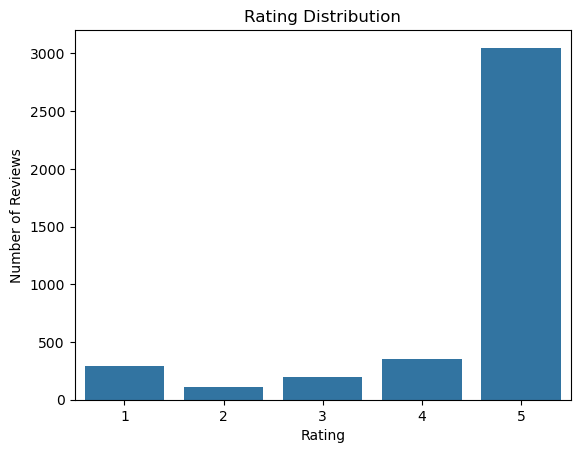

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='score', data=df)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [10]:
df['review_length'] = df['content'].astype(str).apply(len)

df['review_length'].describe()

count    4000.000000
mean       30.143500
std        54.923648
min         1.000000
25%         6.000000
50%        12.000000
75%        29.000000
max       500.000000
Name: review_length, dtype: float64

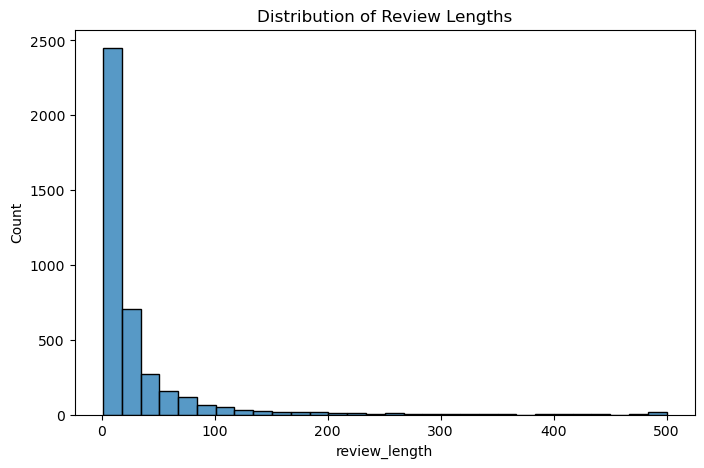

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=30)
plt.title("Distribution of Review Lengths")
plt.show()

In [12]:
df.groupby('score')['review_length'].mean()

score
1    57.993103
2    54.398148
3    64.082051
4    40.229692
5    23.286230
Name: review_length, dtype: float64

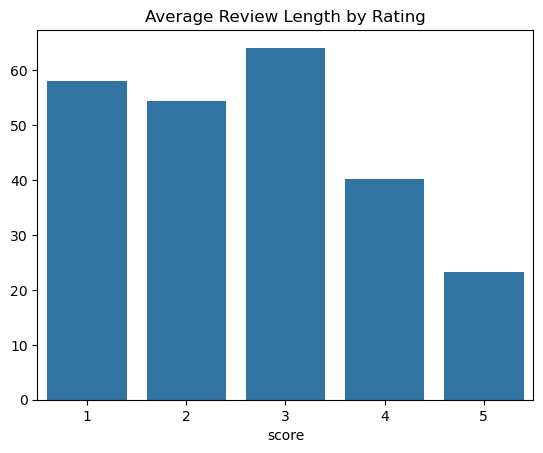

In [13]:
sns.barplot(
    x=df.groupby('score')['review_length'].mean().index,
    y=df.groupby('score')['review_length'].mean().values
)

plt.title("Average Review Length by Rating")
plt.show()

In [14]:
df['at'] = pd.to_datetime(df['at'])

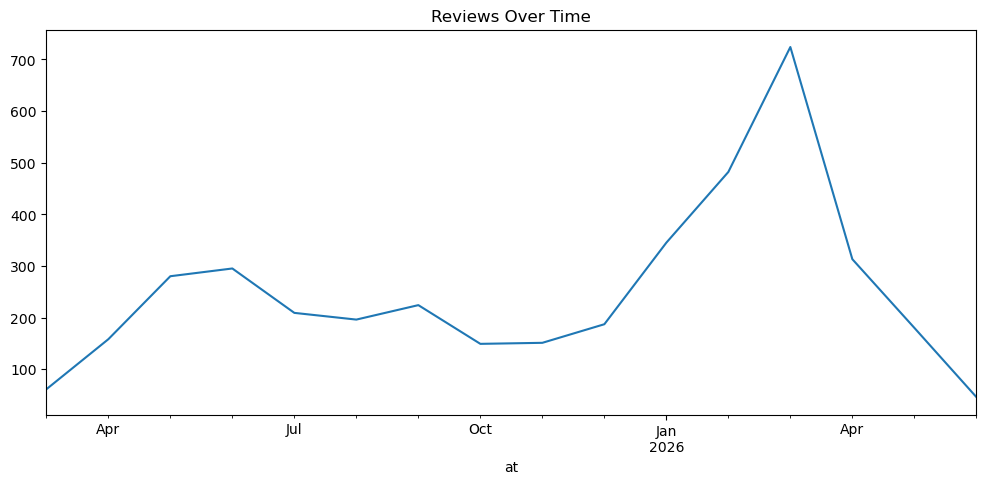

In [15]:
monthly_reviews = df.groupby(df['at'].dt.to_period('M')).size()

monthly_reviews.plot(figsize=(12,5))
plt.title("Reviews Over Time")
plt.show()

In [18]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [21]:
negative = df[df['score'] <= 2]

text = " ".join(negative['content'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

NameError: name 'WordCloud' is not defined

In [22]:
def sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['score'].apply(sentiment)

df['sentiment'].value_counts()

sentiment
Positive    3407
Negative     398
Neutral      195
Name: count, dtype: int64

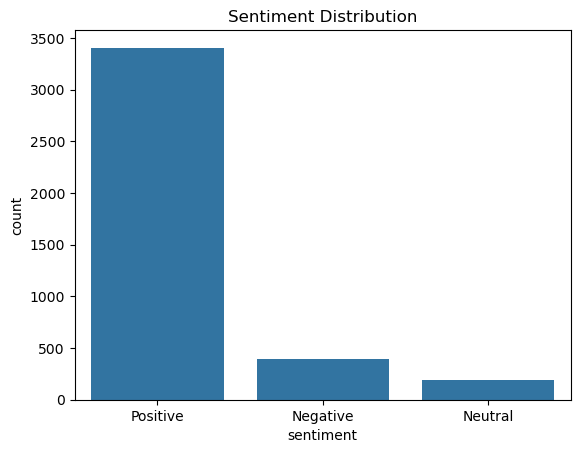

In [23]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()